<a href="https://colab.research.google.com/github/RichaGaharwar/Advanced-Python-Web-Api-Scrapping./blob/main/Web_Api_%26_Scrapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
#WebAPI:

---
API stands for Application Programming Interface

---
API call:

---

* protocol -> HTTP
* Authentication
* Functional request
  * URL for the endpoint
  * Parameters
  * syntax
  * sample responses

In [ ]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

**JavaScript -> scrapy or selenium**

**No JavaScript -> BeautifulSoup**


```
To check which language the website is using:

website -> inspect -> disable javascript -> reload

if the page is working that means javascript is not used
and we can scrape the data using BeautifulSoup

Else use scrapy or Selenium

```

---
Types of requests:

---

* GET
* POST
* PUT
* DELETE


```
We'll have a URL were we'll decide which type of request we want.
```



In [ ]:
url = ''
url = "https://api.ipify.org"
response = requests.get(url)
response

<Response [200]>

---
Response status code:

---

* 1xx -> informational
* 2xx -> success
* 3xx -> redirected
* 4xx -> client error (not found)
* 5xx -> server code

In [ ]:
response.status_code

200

In [ ]:
response.text

'35.252.170.244'

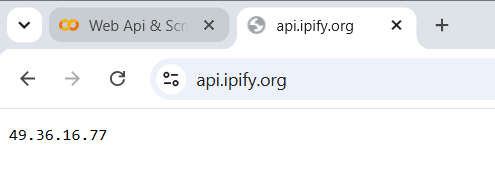

---
Different IP addresses.

---
why?

---
because we are using google colab notebook hence all the computations are happening on a system that google has provided to us (colab) therefore we get different IP adresses
since we are using google's resources so we get google's IP adress as output

#GitHub API

In [ ]:
base_url = "https://api.github.com"

In [ ]:
username = "RichaGaharwar "
url = base_url + 'users/'+ username
url

'https://api.github.comusers/RichaGaharwar '

In [ ]:
username = "RichaGaharwar ".strip()
url = base_url + '/users/' + username
res = requests.get(url)

In [ ]:
res.text

'{"login":"RichaGaharwar","id":124981714,"node_id":"U_kgDOB3MR0g","avatar_url":"https://avatars.githubusercontent.com/u/124981714?v=4","gravatar_id":"","url":"https://api.github.com/users/RichaGaharwar","html_url":"https://github.com/RichaGaharwar","followers_url":"https://api.github.com/users/RichaGaharwar/followers","following_url":"https://api.github.com/users/RichaGaharwar/following{/other_user}","gists_url":"https://api.github.com/users/RichaGaharwar/gists{/gist_id}","starred_url":"https://api.github.com/users/RichaGaharwar/starred{/owner}{/repo}","subscriptions_url":"https://api.github.com/users/RichaGaharwar/subscriptions","organizations_url":"https://api.github.com/users/RichaGaharwar/orgs","repos_url":"https://api.github.com/users/RichaGaharwar/repos","events_url":"https://api.github.com/users/RichaGaharwar/events{/privacy}","received_events_url":"https://api.github.com/users/RichaGaharwar/received_events","type":"User","user_view_type":"public","site_admin":false,"name":"Rich

JSON data

In [ ]:
import json
output = json.loads(res.text)
output

{'login': 'RichaGaharwar',
 'id': 124981714,
 'node_id': 'U_kgDOB3MR0g',
 'avatar_url': 'https://avatars.githubusercontent.com/u/124981714?v=4',
 'gravatar_id': '',
 'url': 'https://api.github.com/users/RichaGaharwar',
 'html_url': 'https://github.com/RichaGaharwar',
 'followers_url': 'https://api.github.com/users/RichaGaharwar/followers',
 'following_url': 'https://api.github.com/users/RichaGaharwar/following{/other_user}',
 'gists_url': 'https://api.github.com/users/RichaGaharwar/gists{/gist_id}',
 'starred_url': 'https://api.github.com/users/RichaGaharwar/starred{/owner}{/repo}',
 'subscriptions_url': 'https://api.github.com/users/RichaGaharwar/subscriptions',
 'organizations_url': 'https://api.github.com/users/RichaGaharwar/orgs',
 'repos_url': 'https://api.github.com/users/RichaGaharwar/repos',
 'events_url': 'https://api.github.com/users/RichaGaharwar/events{/privacy}',
 'received_events_url': 'https://api.github.com/users/RichaGaharwar/received_events',
 'type': 'User',
 'user_v

#Save the image

In [ ]:
output['avatar_url']

'https://avatars.githubusercontent.com/u/124981714?v=4'

save image

In [ ]:
fp = open("{}.png".format(username), 'wb')
img_data = requests.get(output['avatar_url'])
fp.write(img_data.content)
fp.close

<function BufferedWriter.close()>

##Get details about logged in user

In [ ]:
res = requests.get(base_url+"/user")
res

<Response [401]>

Since I haven't logged in I am getting error.

Authentication is required first.


#Web Scrapping

request : beautifulsoup

selenium : browser automation

scrapy: spider web crawling


In [24]:
%pip install requests
import requests
import pandas as pd
from bs4 import BeautifulSoup

## **Lesson:**

In [ ]:
books_info = []

for x in range(1, 51):

  website = (f"https://books.toscrape.com/catalogue/page-{x}.html")
  r = requests.get(website)
  soup = BeautifulSoup(r.content, 'html.parser')
  book = soup.find_all("li", class_ = "col-xs-6 col-sm-4 col-md-3 col-lg-3")

  for item in book:
    name_tag = item.find("h3").find("a")
    book_name = name_tag.text.strip()
    book_link = name_tag["href"]
    price = item.find("p", class_ = "price_color").text.strip()

    all_products = {
        "Name" : book_name,
        "Link" : book_link,
        "Price" : price
    }

  books_info.append(all_products)

df = pd.DataFrame(books_info)
df.to_csv("Books_Info.csv", index = False)


In [ ]:
books = pd.read_csv("Books_Info.csv")
books.head()

,Name,Link,Price
0,It's Only the Himalayas,its-only-the-himalayas_981/index.html,£45.17
1,You can't bury them ...,you-cant-bury-them-all-poems_961/index.html,£33.63
2,The Natural History of ...,the-natural-history-of-us-the-fine-art-of-pret...,£45.22
3,"Rat Queens, Vol. 3: ...",rat-queens-vol-3-demons-rat-queens-collected-e...,£50.40
4,In the Country We ...,in-the-country-we-love-my-family-divided_901/i...,£22.00


## **quotes data:**

In [14]:
quotes_data = []
website = "https://quotes.toscrape.com/"
r = requests.get(website)
soup = BeautifulSoup(r.content, "html.parser")
quotes = soup.find_all("div", class_ = "quote")

In [15]:
for item in quotes:
  quote = item.find("span", class_ = "text").text.strip()
  author = item.find("small", class_ = "author").text.strip()
  author_link = item.find("a")["href"]
  tags = item.find("meta")["content"]
  data = {
      "Quote" : quote,
      "Author" : author,
      "Tags" : tags,
      "author_link" : author_link
  }
  quotes_data.append(data)

In [16]:
df = pd.DataFrame(quotes_data)
df.to_csv("quotes_data.csv", index = False)

In [17]:
df = pd.read_csv("quotes_data.csv")
df.head()

,Quote,Author,Tags,author_link
0,“The world as we have created it is a process ...,Albert Einstein,"change,deep-thoughts,thinking,world",/author/Albert-Einstein
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities,choices",/author/J-K-Rowling
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational,life,live,miracle,miracles",/author/Albert-Einstein
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy,books,classic,humor",/author/Jane-Austen
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself,inspirational",/author/Marilyn-Monroe


## **YC Data:**

In [21]:
yc_data  = []
website = "https://news.ycombinator.com/news"
r = requests.get(website)
soup = BeautifulSoup(r.text, "html.parser")
yc = soup.find_all("tr", class_ = "athing")
#title_text = soup.select(".titleline > a")



In [23]:
for i in yc:
  title_text = i.find_all("span", class_ = "titleline")
  for a in title_text:
    print(a.get_text(strip=True))

  # title_link = i.find("a")["href"]
  # subtext_row = i.find_next_sibling("tr")
  # score_span = subtext_row.find("span", class_="score") if subtext_row else None
  # score = score_span.text.strip() if score_span else "0 points"

  # data = {"Title" : title_text, "Link" : title_link, "Score" : score}
  # yc_data.append(data)

AttributeError: ResultSet object has no attribute "get_text". You're probably treating a list of elements like a single element. Did you call find_all() when you meant to call find()?

In [26]:
yc_data

[{'Title': '',
  'Link': 'vote?id=50002008&how=up&goto=news',
  'Score': '175 points'},
 {'Title': '',
  'Link': 'vote?id=49996437&how=up&goto=news',
  'Score': '814 points'},
 {'Title': '',
  'Link': 'vote?id=49970767&how=up&goto=news',
  'Score': '140 points'},
 {'Title': '',
  'Link': 'vote?id=50001580&how=up&goto=news',
  'Score': '57 points'},
 {'Title': '',
  'Link': 'vote?id=49998895&how=up&goto=news',
  'Score': '1254 points'},
 {'Title': '',
  'Link': 'vote?id=50002494&how=up&goto=news',
  'Score': '5 points'},
 {'Title': '',
  'Link': 'vote?id=49969073&how=up&goto=news',
  'Score': '143 points'},
 {'Title': '',
  'Link': 'vote?id=49959280&how=up&goto=news',
  'Score': '37 points'},
 {'Title': '',
  'Link': 'vote?id=49966866&how=up&goto=news',
  'Score': '9 points'},
 {'Title': '',
  'Link': 'vote?id=49982445&how=up&goto=news',
  'Score': '120 points'},
 {'Title': '',
  'Link': 'vote?id=49998066&how=up&goto=news',
  'Score': '126 points'},
 {'Title': '',
  'Link': 'vote?id=499

## **Practise:**

In [26]:
yc_datas = []
website = "https://news.ycombinator.com/news"
r = requests.get(website)
soup = BeautifulSoup(r.content, "html.parser")
yc = soup.find_all("tr", class_ = "athing")

In [35]:
for i in yc:
  title = i.find("span", class_ = "titleline").find("a").text.strip()
  print(title)


“Math 2.0” will need to value mathematical progress more holistically
Claude Haiku 5.5
The 15-year search for a band that charted once and vanished
Living off-grid: Hundred Rabbits
The Slow Formation of Durable Software
Margaret Hamilton has died
GPT‑6 and Intelligent UI for everyone
How did Rosalind Franklin miss the helix in her iconic DNA image? She didn't
'Jonathan' is the oldest land animal on Earth
The Mathocalypse
Classic PC demoscene productions running natively in the browser
Cleo (Mathematician)
Show HN: Bigwords.page – Turn any screen into a sign. The URL is the app
Dat-ecosystem: high level applications built on top of P2P protocols
In Vienna and Beijing, the first (thorium) nuclear clocks begin to tick
Bloody Cavemen
Docker Agent
Sharing AI progress in mathematics
New repository settings for configuring pull request access
Push ifs up and fors down: The idiom, its algebra, and its limits
Analog Computer Simulator in the Browser
Animated ASCII Art for Web Pages
Why were Vic

In [46]:

for i in yc:
  title = i.find("span", class_ = "titleline").find("a").get_text(strip = True)
  title_link = i.find("a")["href"]
  data = {
      "Title" : title,
      "Link" : title_link
  }
print(data)

{'Title': 'Port of the TypeScript compiler, checker and lsp to Rust, by LLM', 'Link': 'vote?id=50000676&how=up&goto=news'}


In [52]:
yc1 = soup.find_all("tr", class_ = "subtext")
for i in yc1:
  score = i.find("span", class_ = "score").text.strip()
  data.append({"score":score})
  print(data)

In [53]:
print(data)

{'Title': 'Port of the TypeScript compiler, checker and lsp to Rust, by LLM', 'Link': 'vote?id=50000676&how=up&goto=news'}


In [31]:
for i in yc:
  title = i.find("span", class_ = "titleline")
  title_text = title.find("a").get_text(strip = True)
  print(title_text)

“Math 2.0” will need to value mathematical progress more holistically
Claude Haiku 5.5
The 15-year search for a band that charted once and vanished
Living off-grid: Hundred Rabbits
The Slow Formation of Durable Software
Margaret Hamilton has died
GPT‑6 and Intelligent UI for everyone
How did Rosalind Franklin miss the helix in her iconic DNA image? She didn't
'Jonathan' is the oldest land animal on Earth
The Mathocalypse
Classic PC demoscene productions running natively in the browser
Cleo (Mathematician)
Show HN: Bigwords.page – Turn any screen into a sign. The URL is the app
Dat-ecosystem: high level applications built on top of P2P protocols
In Vienna and Beijing, the first (thorium) nuclear clocks begin to tick
Bloody Cavemen
Docker Agent
Sharing AI progress in mathematics
New repository settings for configuring pull request access
Push ifs up and fors down: The idiom, its algebra, and its limits
Analog Computer Simulator in the Browser
Animated ASCII Art for Web Pages
Why were Vic